# Transformer on PLAsTiCC: using GP fits to lightcurves

This notebook uses the `dlip_plasticc` package on top of `avocado`.

### Notebook parameters

In [42]:
# Notebook parameters

CONFIG_DEFAULT_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/default.toml'
CONFIG_LOCAL_PATH = '/home6/s4339150/Courses/dlip_plasticc/configs/local.toml'

# Training
TRAIN_DATASET_NAME = 'plasticc_augment_gp'
CLASSIFIER_NAME = 'my_transformer_gp'
SEQ_LEN = 350
NUM_EPOCHS = 60
BATCH_SIZE = 64
LR = 1e-4
NUM_FOLDS = 5
RANDOM_STATE = 42
VAL_FOLD = 0
WEIGHT_DECAY = 5e-2
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
MIN_LR = 1e-6
EARLY_STOPPING_PATIENCE = 8

# Transformer architecture
D_MODEL = 128
NHEAD = 4
NUM_LAYERS = 4
DIM_FEEDFORWARD = 512
DROPOUT = 0.3

# Prediction
TEST_DATASET_NAME = 'plasticc_test_gp'
TOTAL_CHUNKS = 500

# Change this list to the chunks you actually want to run.
# For a quick smoke test, use something like [0, 1, 2].
CHUNKS = range(21)

# Output location for per-chunk and combined predictions.
OUT_DIR = 'notebook_outputs/transformer_GP_predictions'

# Confusion matrix display options
CONFUSION_NORMALIZE = 'true'  # one of: None, 'true', 'pred', 'all'
FIGSIZE_HISTORY = (8, 5)
FIGSIZE_CONFUSION = (10, 8)


### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import gc
import torch

from pathlib import Path

import avocado

from dlip_plasticc.config import load_config, apply_avocado_settings
from dlip_plasticc.features import PlasticcSequenceFeaturizer
from dlip_plasticc.models import TransformerClassifier
from dlip_plasticc.pipelines.predict import predict_partial_from_dataset
from dlip_plasticc.pipelines.score import score_flat, align_truth_and_predictions

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


### Paths

These are set by the `avocado_settings.json` file.

In [ ]:
cfg = load_config(CONFIG_DEFAULT_PATH, CONFIG_LOCAL_PATH)
apply_avocado_settings(cfg)

print('Using avocado paths:')
print('  data_directory       =', avocado.settings['data_directory'])
print('  features_directory   =', avocado.settings['features_directory'])
print('  predictions_directory=', avocado.settings['predictions_directory'])
print('  classifier_directory =', avocado.settings['classifier_directory'])


Using avocado paths:
  data_directory       = /scratch/s4339150/plasticc/data
  features_directory   = /scratch/s4339150/plasticc/features
  predictions_directory= /scratch/s4339150/plasticc/predictions
  classifier_directory = /scratch/s4339150/plasticc/classifiers


## 1. Preprocess the data

We use gaussian-process fitted lightcurves, but since they are different from the default datasets avocado expects (e.g. features, or raw data), we need some preprocessing.

In [ ]:
with h5py.File('/scratch/s4339150/plasticc/data/plasticc_augment_gp.h5', 'r') as f:
    object_id     = f['object_id'][:].astype(str)
    cont_features = f['cont_features'][:]
    band_ids      = f['band_ids'][:]
    mask          = f['mask'][:]

print('object_id:',     object_id.shape)
print('cont_features:', cont_features.shape)
print('band_ids:',      band_ids.shape)
print('mask:',          mask.shape)

object_id: (66532,)
cont_features: (66532, 200, 13)
band_ids: (66532, 200)
mask: (66532, 200)


In [ ]:
class H5TrainDataset:
    def __init__(self, h5_path, avocado_dataset):
        with h5py.File(h5_path, 'r') as f:
            object_ids         = f['object_id'][:].astype(str)
            self.cont_features = f['cont_features'][:]
            self.band_ids      = f['band_ids'][:]
            self.mask          = f['mask'][:]

        self._object_ids      = object_ids
        self._avocado_dataset = avocado_dataset
        self.metadata         = avocado_dataset.metadata.loc[object_ids]

    def select_features(self, featurizer):
        return (self.cont_features, self.band_ids, self.mask)

    def label_folds(self, num_folds, random_state):
        folds = self._avocado_dataset.label_folds(num_folds, random_state)
        # re-index to match h5 row order exactly
        return folds.loc[self._object_ids].reset_index(drop=True)
    
print(f"Loading training dataset '{TRAIN_DATASET_NAME}'...")
avocado_dataset = avocado.load('plasticc_augment', metadata_only=True)  # no .metadata
train_dataset   = H5TrainDataset(
    '/scratch/s4339150/plasticc/data/plasticc_augment_gp.h5',
    avocado_dataset,
)

## 2. Train the transformer


In [ ]:
gc.collect()
torch.cuda.empty_cache()

classifier = TransformerClassifier(
    name=CLASSIFIER_NAME,
    featurizer=None,       
    num_epochs=NUM_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    auto_class_weights=True,   
)

print(f"Training classifier '{CLASSIFIER_NAME}'...")
classifier.train(
    train_dataset,
    num_folds=NUM_FOLDS,
    random_state=RANDOM_STATE,
    val_fold=VAL_FOLD,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_factor=LR_SCHEDULER_FACTOR,
    lr_scheduler_patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LR,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    show_progress=True,
)

print(f"Best validation loss: {classifier.best_val_loss:.5f}")

Loading training dataset 'plasticc_augment_gp'...
Training classifier 'my_transformer_gp'...


Epochs:   2%|▏         | 1/60 [00:12<12:44, 12.96s/it]

Epoch 1 train_loss: 1.70744 val_loss: 1.49132 val_acc: 0.42262 lr: 1.000000e-04


Epochs:   3%|▎         | 2/60 [00:29<14:26, 14.94s/it]

Epoch 2 train_loss: 1.36030 val_loss: 1.28855 val_acc: 0.49001 lr: 1.000000e-04


...

Epoch 16 train_loss: 0.98444 val_loss: 1.03342 val_acc: 0.56077 lr: 5.000000e-05


Epochs:  28%|██▊       | 17/60 [06:07<16:39, 23.24s/it]

Epoch 17 train_loss: 0.97146 val_loss: 1.05953 val_acc: 0.53071 lr: 5.000000e-05


Epochs:  30%|███       | 18/60 [06:31<16:18, 23.29s/it]

Epoch 18 train_loss: 0.96933 val_loss: 1.06464 val_acc: 0.55681 lr: 5.000000e-05


In [28]:
# Save the trained classifier
classifier.write(overwrite=True)
print('Classifier written to:', classifier.path)


Classifier written to: /scratch/s4339150/plasticc/classifiers/classifier_my_transformer_gp.pkl


## 2. Plot training history

In [33]:
history = classifier.history.copy()
history.tail()

,epoch,train_loss,val_loss,val_acc,lr
28,29,0.959216,1.094406,0.530855,0.000006
29,30,0.957632,1.090038,0.532052,0.000006
30,31,0.959543,1.102229,0.524647,0.000003
31,32,0.957808,1.091203,0.526442,0.000003
32,33,0.953418,1.090055,0.529434,0.000003


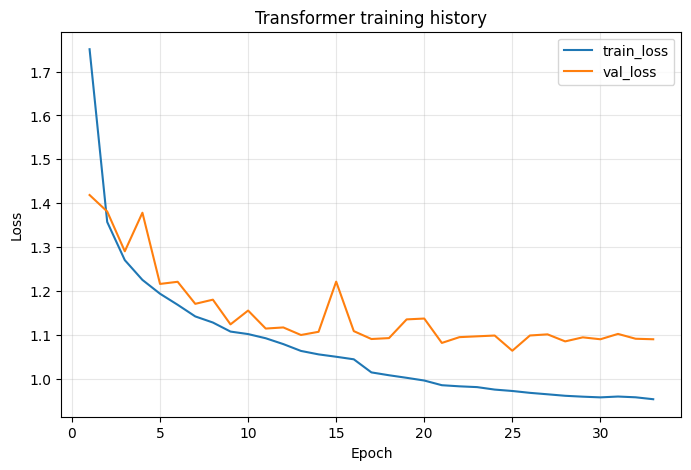

In [ ]:
fig, ax = plt.subplots(figsize=FIGSIZE_HISTORY)
ax.plot(history['epoch'], history['train_loss'], label='Training loss')
ax.plot(history['epoch'], history['val_loss'], label='Validation loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Log-loss')
ax.set_title('Transformer training history')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


## 3. Predict on test set

In [ ]:
# Load the trained classifier for prediction and scoring if needed 
classifier = avocado.load_classifier(CLASSIFIER_NAME)

### Prepare test set

In [24]:
class H5Dataset:
    def __init__(self, h5_path, avocado_dataset):
        with h5py.File(h5_path, 'r') as f:
            object_ids         = f['object_id'][:].astype(str)
            self.cont_features = f['cont_features'][:]
            self.band_ids      = f['band_ids'][:]
            self.mask          = f['mask'][:]

        self._object_ids      = object_ids
        self._avocado_dataset = avocado_dataset
        # use reindex instead of loc — fills missing ids with NaN instead of KeyError
        self.metadata         = avocado_dataset.metadata.reindex(object_ids)

    def select_features(self, featurizer):
        return (self.cont_features, self.band_ids, self.mask)

    def label_folds(self, num_folds, random_state):
        folds = self._avocado_dataset.label_folds(num_folds, random_state)
        return folds.loc[self._object_ids].reset_index(drop=True)


avocado_test = avocado.load('plasticc_test', metadata_only=True)
test_dataset = H5Dataset('/scratch/s4339150/plasticc/data/plasticc_test_gp.h5', avocado_test)

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

def predict_batched(classifier, dataset, batch_size=512):
    """Predict in batches to avoid OOM."""
    cont_features, band_ids, mask = dataset.select_features(None)
    global_feats = classifier._derive_global_features(cont_features, mask)

    n = cont_features.shape[0]
    all_probs = []

    classifier.model.eval()
    with torch.no_grad():
        for start in range(0, n, batch_size):
            end = min(start + batch_size, n)

            xc = torch.tensor(cont_features[start:end], dtype=torch.float32).to(classifier.device)
            xb = torch.tensor(band_ids[start:end],      dtype=torch.long).to(classifier.device)
            m  = torch.tensor(mask[start:end],           dtype=torch.float32).to(classifier.device)
            g  = torch.tensor(global_feats[start:end],  dtype=torch.float32).to(classifier.device)

            logits = classifier.model(xc, xb, m, g)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)

    all_probs = np.concatenate(all_probs, axis=0)

    return pd.DataFrame(
        all_probs,
        index=dataset.metadata.index,
        columns=classifier.class_names,
    )

# usage
preds = predict_batched(classifier, test_dataset, batch_size=512)
print(preds.shape)
preds.head()

(146701, 14)


,6,15,16,42,52,53,62,64,65,67,88,90,92,95
object_id,,,,,,,,,,,,,,
plasticc_000000013,0.000601,0.011099,1.292834e-06,0.343279,0.113517,1.926171e-07,0.135507,0.000593,0.000606,0.033856,0.000227,0.180609,2.694365e-07,0.180105
plasticc_000000014,0.000191,0.000851,1.239575e-05,0.519647,0.243869,1.784169e-07,0.159225,0.000041,0.036298,0.001946,0.001462,0.033961,1.881024e-06,0.002494
plasticc_000000017,0.000059,0.000406,1.234541e-05,0.253652,0.485488,1.228661e-08,0.172515,0.000086,0.010910,0.011319,0.000951,0.059901,1.082856e-06,0.004700
plasticc_000000023,0.001517,0.000217,3.044303e-06,0.101088,0.052307,3.172131e-07,0.572970,0.000265,0.001390,0.079124,0.000048,0.091495,8.815593e-07,0.099575
plasticc_000000034,0.000092,0.000224,1.794815e-07,0.046592,0.166588,5.991046e-11,0.096883,0.000475,0.000242,0.050133,0.000002,0.637486,5.980867e-09,0.001282


## 4. Score predictions with avocado flat-weighted logloss

This scores only on the overlapping labeled objects available in the metadata.

In [25]:
flat_score, n_scored = score_flat(
    avocado_test.metadata,   # pass metadata directly instead of TEST_DATASET_NAME
    preds,
)
print(f'Flat-weighted logloss: {flat_score:.5f}')
print(f'Objects scored:        {n_scored:,}')

Flat-weighted logloss: 0.98368
Objects scored:        146,085


## 5. Confusion matrix

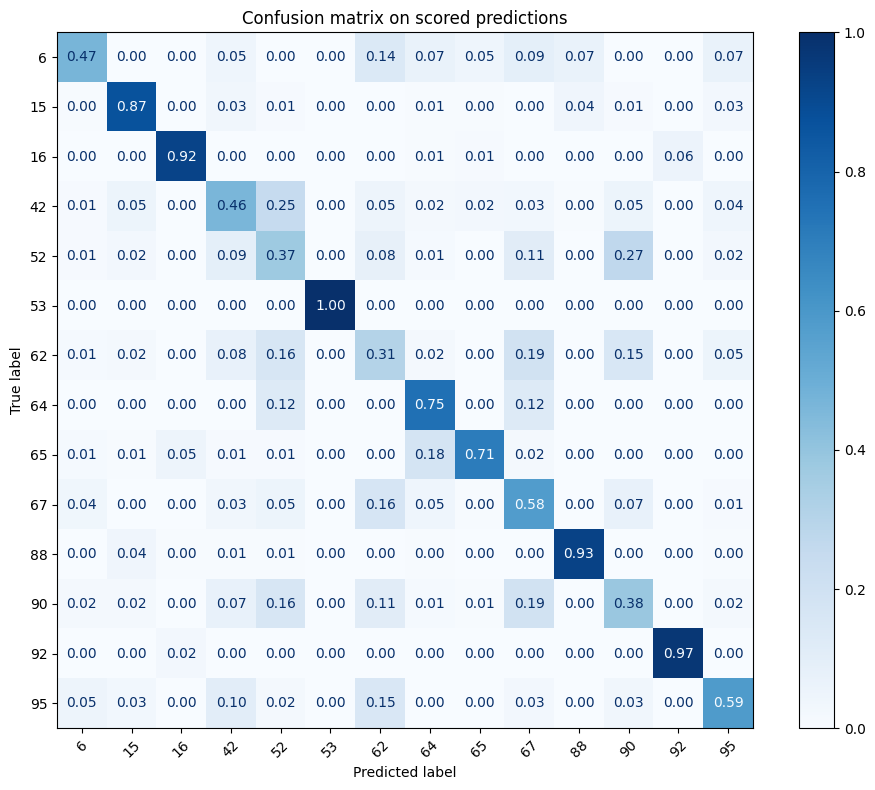

In [26]:
y_true, pred_aligned = align_truth_and_predictions(
    avocado_test.metadata,   # instead of TEST_DATASET_NAME
    preds,
    known_classes_only=True,
    normalize=True,
)

y_pred = pred_aligned.idxmax(axis=1)
labels = sorted(np.unique(np.concatenate([y_true.values, y_pred.values])))

cm = confusion_matrix(y_true, y_pred, labels=labels, normalize=CONFUSION_NORMALIZE)

fig, ax = plt.subplots(figsize=FIGSIZE_CONFUSION)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels,
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    colorbar=True,
    cmap=plt.cm.Blues,
    values_format=".2f",
)

ax.set_title("Confusion matrix on scored predictions")
plt.tight_layout()
plt.show()

In [27]:
print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           6     0.0108    0.4651    0.0211        43
          15     0.0853    0.8685    0.1553       479
          16     0.8872    0.9242    0.9053      3233
          42     0.7912    0.4619    0.5833     48142
          52     0.0422    0.3733    0.0758      2864
          53     0.7541    1.0000    0.8598        46
          62     0.1860    0.3067    0.2316      7859
          64     0.0020    0.7500    0.0040         8
          65     0.5823    0.7050    0.6378      3095
          67     0.0569    0.5780    0.1037      1673
          88     0.9019    0.9287    0.9151      3743
          90     0.8438    0.3834    0.5273     66848
          92     0.9724    0.9724    0.9724      6781
          95     0.1550    0.5854    0.2451      1271

    accuracy                         0.4709    146085
   macro avg     0.4479    0.6645    0.4455    146085
weighted avg     0.7604    0.4709    0.5537    146085

